<a href="https://colab.research.google.com/github/antiat/ML_stud_practice_2026_3rd_course/blob/main/Stud_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Подготовка к обучению.**

Импорт библиотек.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

Загрузка данных

In [ ]:
df = pd.read_csv('stress_dataset.csv')

print(df.head())
print(df.info())

   anxiety_level  self_esteem  mental_health_history  depression  headache  \
0           10.0         15.0                      1         8.0       2.0   
1           11.0         20.0                      1         5.0       2.0   
2           11.0          NaN                      1        17.0       3.0   
3           10.0         15.0                      0        13.0       3.0   
4           10.0         20.0                      0        12.0       3.0   

   blood_pressure  sleep_quality  breathing_problem  noise_level  \
0               2            2.0                  3          0.0   
1               2            5.0                  2          0.0   
2               3            3.0                  3          2.0   
3               3            2.0                  3          3.0   
4               2            2.0                  2          1.0   

   living_conditions  ...  basic_needs  academic_performance  study_load  \
0                  4  ...            2        

Проверка пропусков.

In [ ]:
print(df.isnull().sum())

anxiety_level                   253
self_esteem                     339
mental_health_history             0
depression                      155
headache                        192
blood_pressure                    0
sleep_quality                   160
breathing_problem                 0
noise_level                     257
living_conditions                 0
safety                            0
basic_needs                       0
academic_performance              0
study_load                      330
teacher_student_relationship      0
future_career_concerns            0
social_support                  169
peer_pressure                     0
extracurricular_activities        0
bullying                          0
stress_level                      0
dtype: int64


Визуализация.

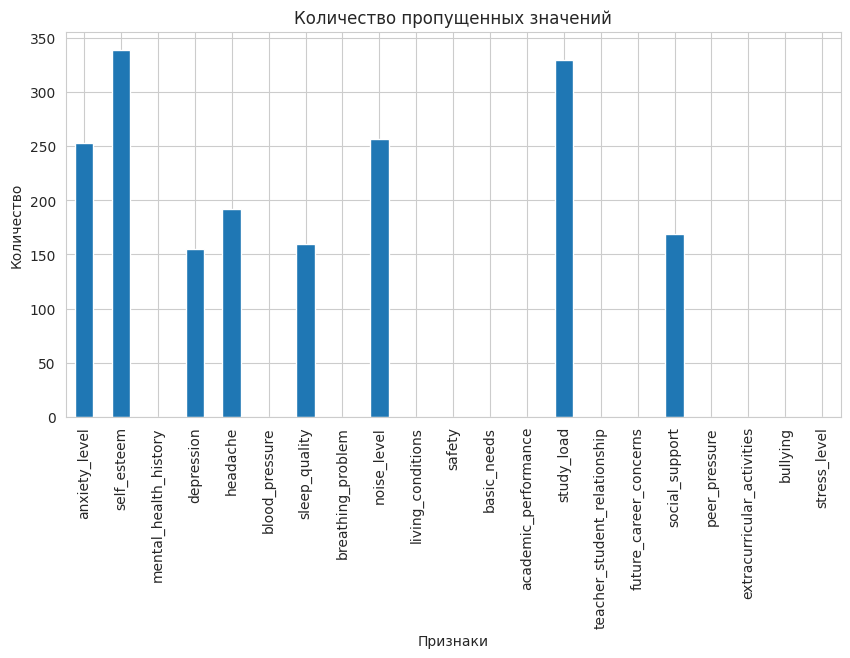

In [ ]:
missing = df.isnull().sum()

plt.figure(figsize=(10,5))
missing.plot(kind='bar')

plt.title('Количество пропущенных значений')
plt.xlabel('Признаки')
plt.ylabel('Количество')

plt.show()

In [ ]:
## Удаление ошибок
df = df.dropna()

Кодирование категориальных признаков

In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

Разделение данных

In [ ]:
X = df.drop('stress_level', axis=1)
y = df['stress_level']

Train/Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Масштабирование

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Обучение моделей**

Logistic regression

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print(accuracy_score(y_test, pred_lr))

0.8613269575612672


Decision Tree

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print(accuracy_score(y_test, pred_dt))

0.7890017931858936


Random Forest

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(accuracy_score(y_test, pred_rf))

0.8661087866108786


KNN

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print(accuracy_score(y_test, pred_knn))

0.8272564255827854


Classification report

In [ ]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.88      0.91       575
           1       0.77      0.84      0.80       547
           2       0.91      0.87      0.89       551

    accuracy                           0.87      1673
   macro avg       0.87      0.87      0.87      1673
weighted avg       0.87      0.87      0.87      1673



Матрица ошибок

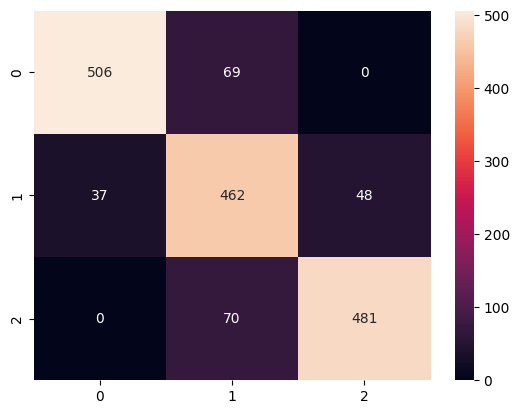

In [ ]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

# **Визуализация**

Импорт библиотек для визуализации

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

Размер датасета

In [ ]:
print("Размер датасета:", df.shape)

Размер датасета: (8365, 21)


Информация о данных

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8365 entries, 0 to 10078
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 8365 non-null   float64
 1   self_esteem                   8365 non-null   float64
 2   mental_health_history         8365 non-null   int64  
 3   depression                    8365 non-null   float64
 4   headache                      8365 non-null   float64
 5   blood_pressure                8365 non-null   int64  
 6   sleep_quality                 8365 non-null   float64
 7   breathing_problem             8365 non-null   int64  
 8   noise_level                   8365 non-null   float64
 9   living_conditions             8365 non-null   int64  
 10  safety                        8365 non-null   int64  
 11  basic_needs                   8365 non-null   int64  
 12  academic_performance          8365 non-null   int64  
 13  study_l

Статистика по данным

In [ ]:
df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,8365.000000,8365.000000,8365.000000,8365.000000,8365.000000,8365.000000,8365.000000,8365.000000,8365.000000,8365.000000,...,8365.000000,8365.000000,8365.000000,8365.000000,8365.000000,8365.000000,8365.000000,8365.000000,8365.000000,8365.000000
mean,10.129588,18.185655,0.297908,12.054871,2.079259,2.003347,2.945129,2.014943,1.989958,2.978721,...,2.981710,2.969038,2.956724,2.992588,2.942020,1.950389,2.966288,2.952779,2.019845,0.997131
std,5.117948,5.678631,0.457366,6.488501,2.069698,0.703709,1.416402,1.288915,1.247818,1.239505,...,1.245086,1.357225,1.255706,1.239279,1.355986,0.897977,1.247498,1.230896,1.333485,0.811350
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,15.000000,0.000000,8.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,10.000000,18.000000,0.000000,12.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,2.000000,1.000000
75%,13.000000,21.000000,1.000000,16.000000,3.000000,2.000000,4.000000,3.000000,3.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,2.000000
max,60.000000,100.000000,1.000000,80.000000,50.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


Распределение уровня стресса

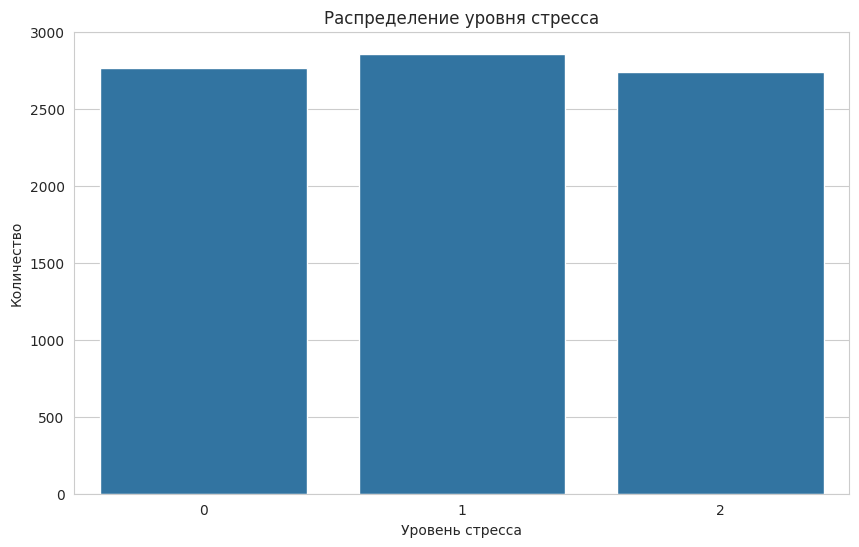

In [ ]:
sns.countplot(x='stress_level', data=df)

plt.title('Распределение уровня стресса')
plt.xlabel('Уровень стресса')
plt.ylabel('Количество')

plt.show()

Гистограммы числовых признаков

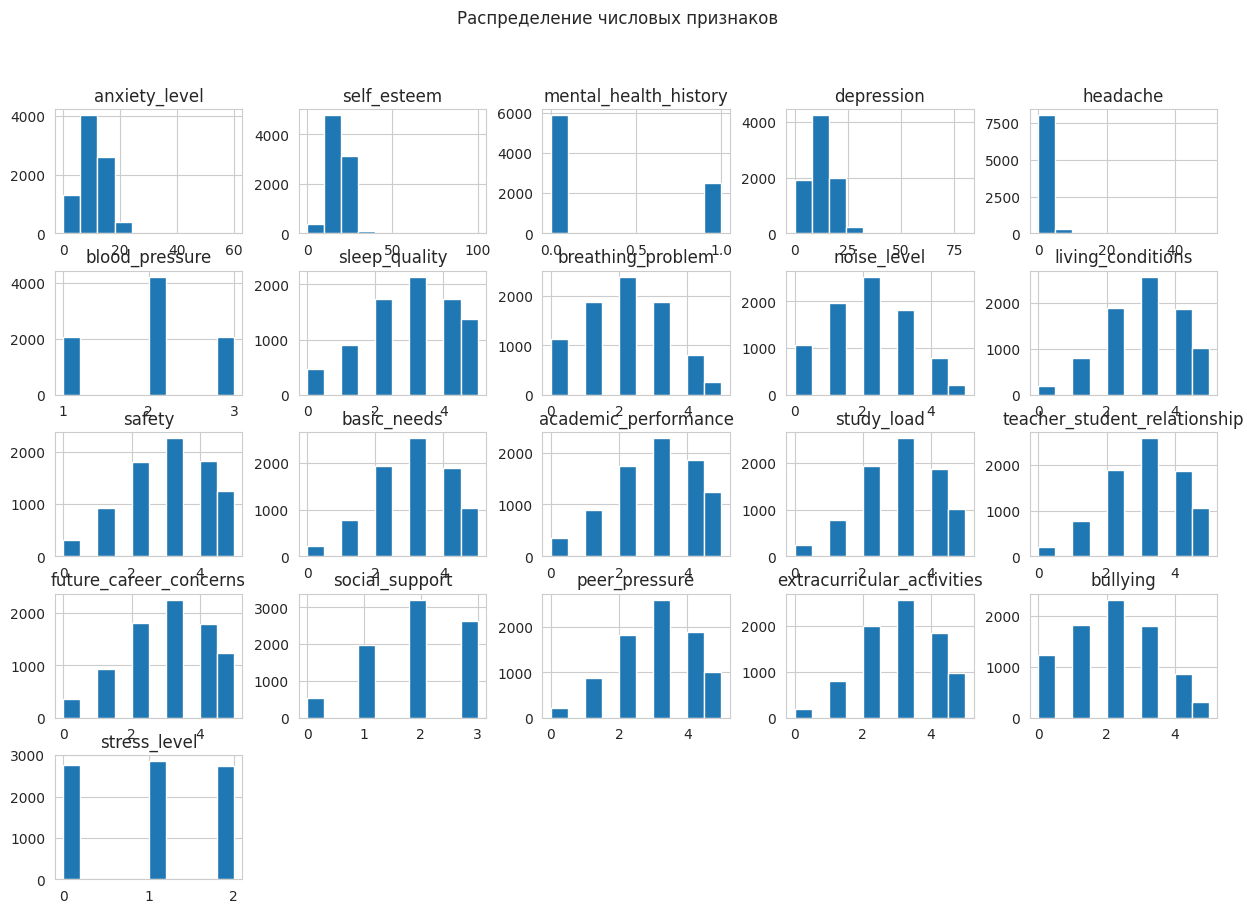

In [ ]:
df.hist(figsize=(15,10))

plt.suptitle('Распределение числовых признаков')

plt.show()

Корреляционная матрица

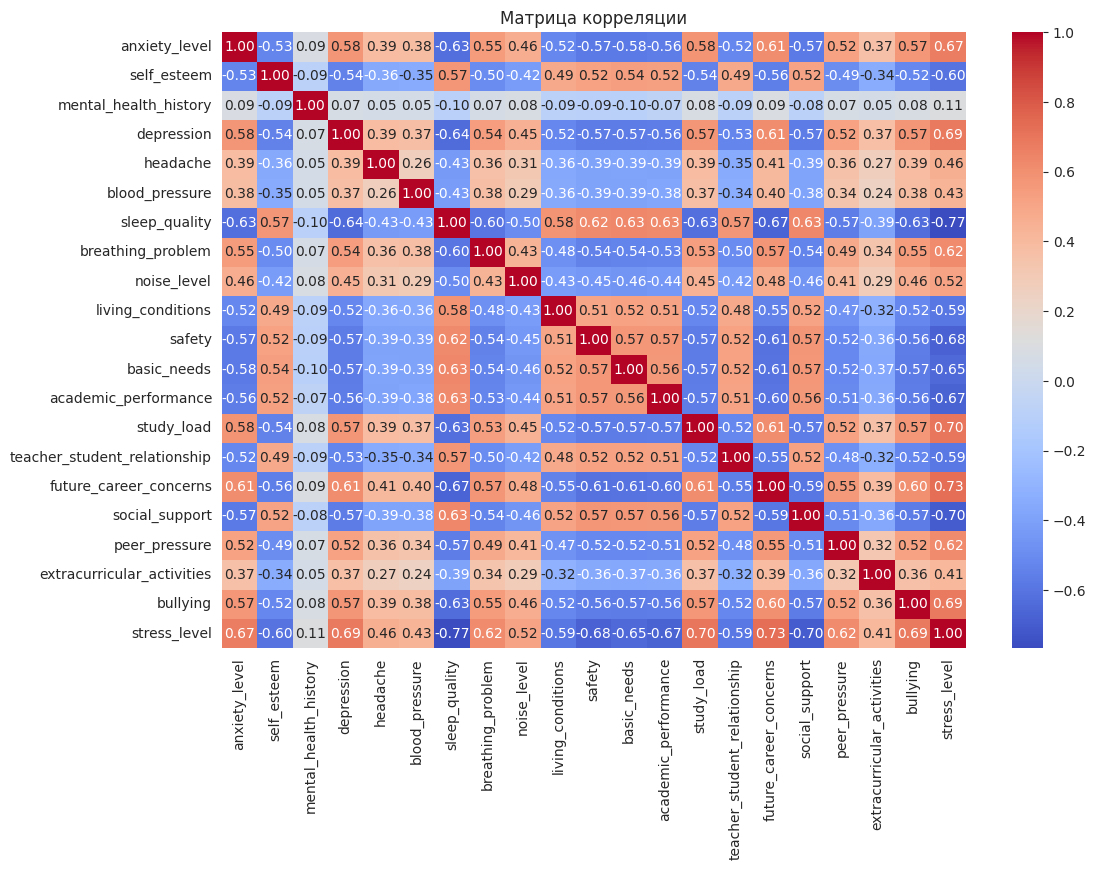

In [ ]:
plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Матрица корреляции')

plt.show()

Boxplot - выбросы

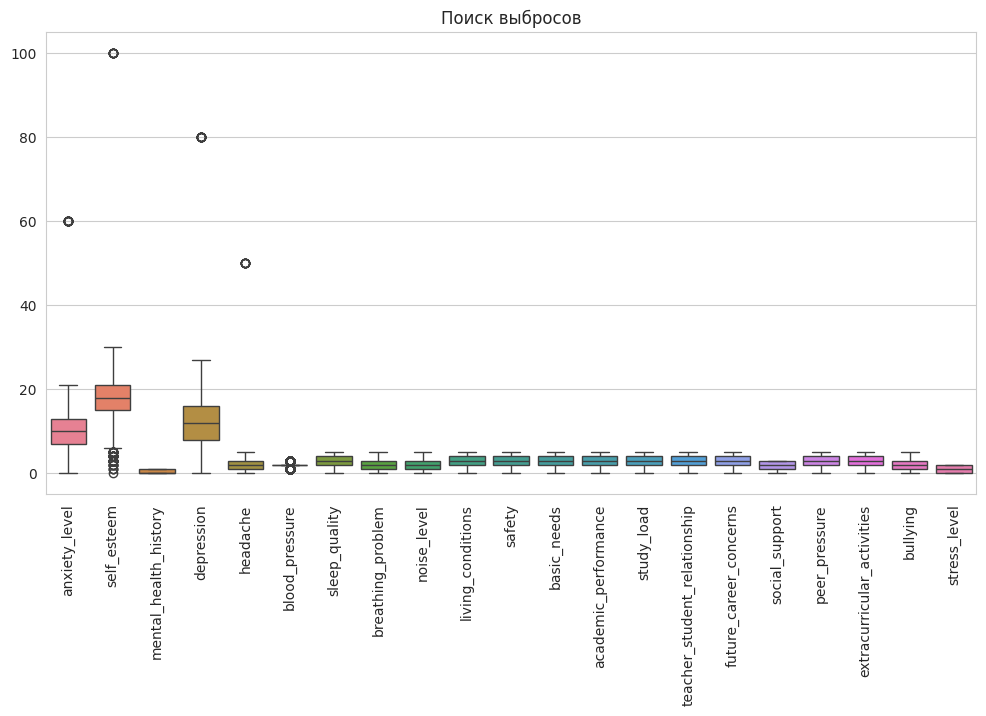

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title('Поиск выбросов')

plt.show()

Зависимость сна и уровня стресса

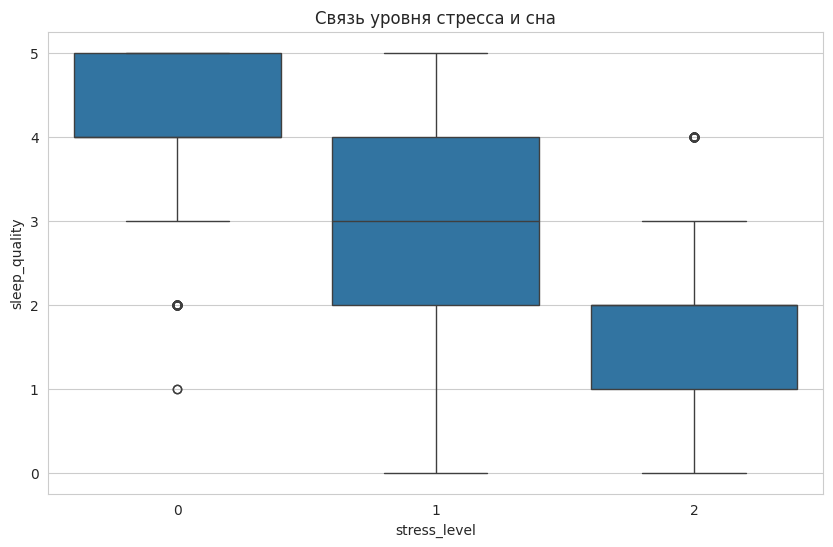

In [ ]:
sns.boxplot(
    x='stress_level',
    y='sleep_quality',
    data=df
)

plt.title('Связь уровня стресса и сна')

plt.show()

Связь стресса и уровня жизни

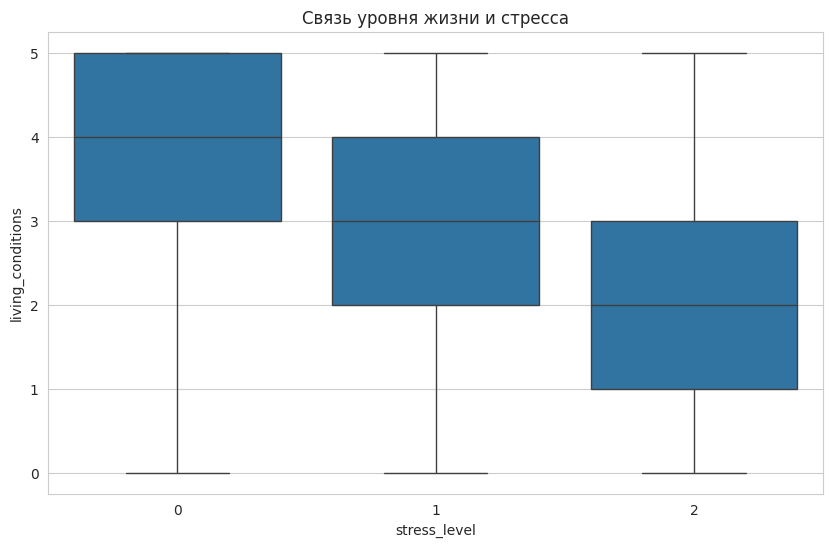

In [ ]:
sns.boxplot(
    x='stress_level',
    y='living_conditions',
    data=df
)

plt.title('Связь уровня жизни и стресса')

plt.show()

Pairplot

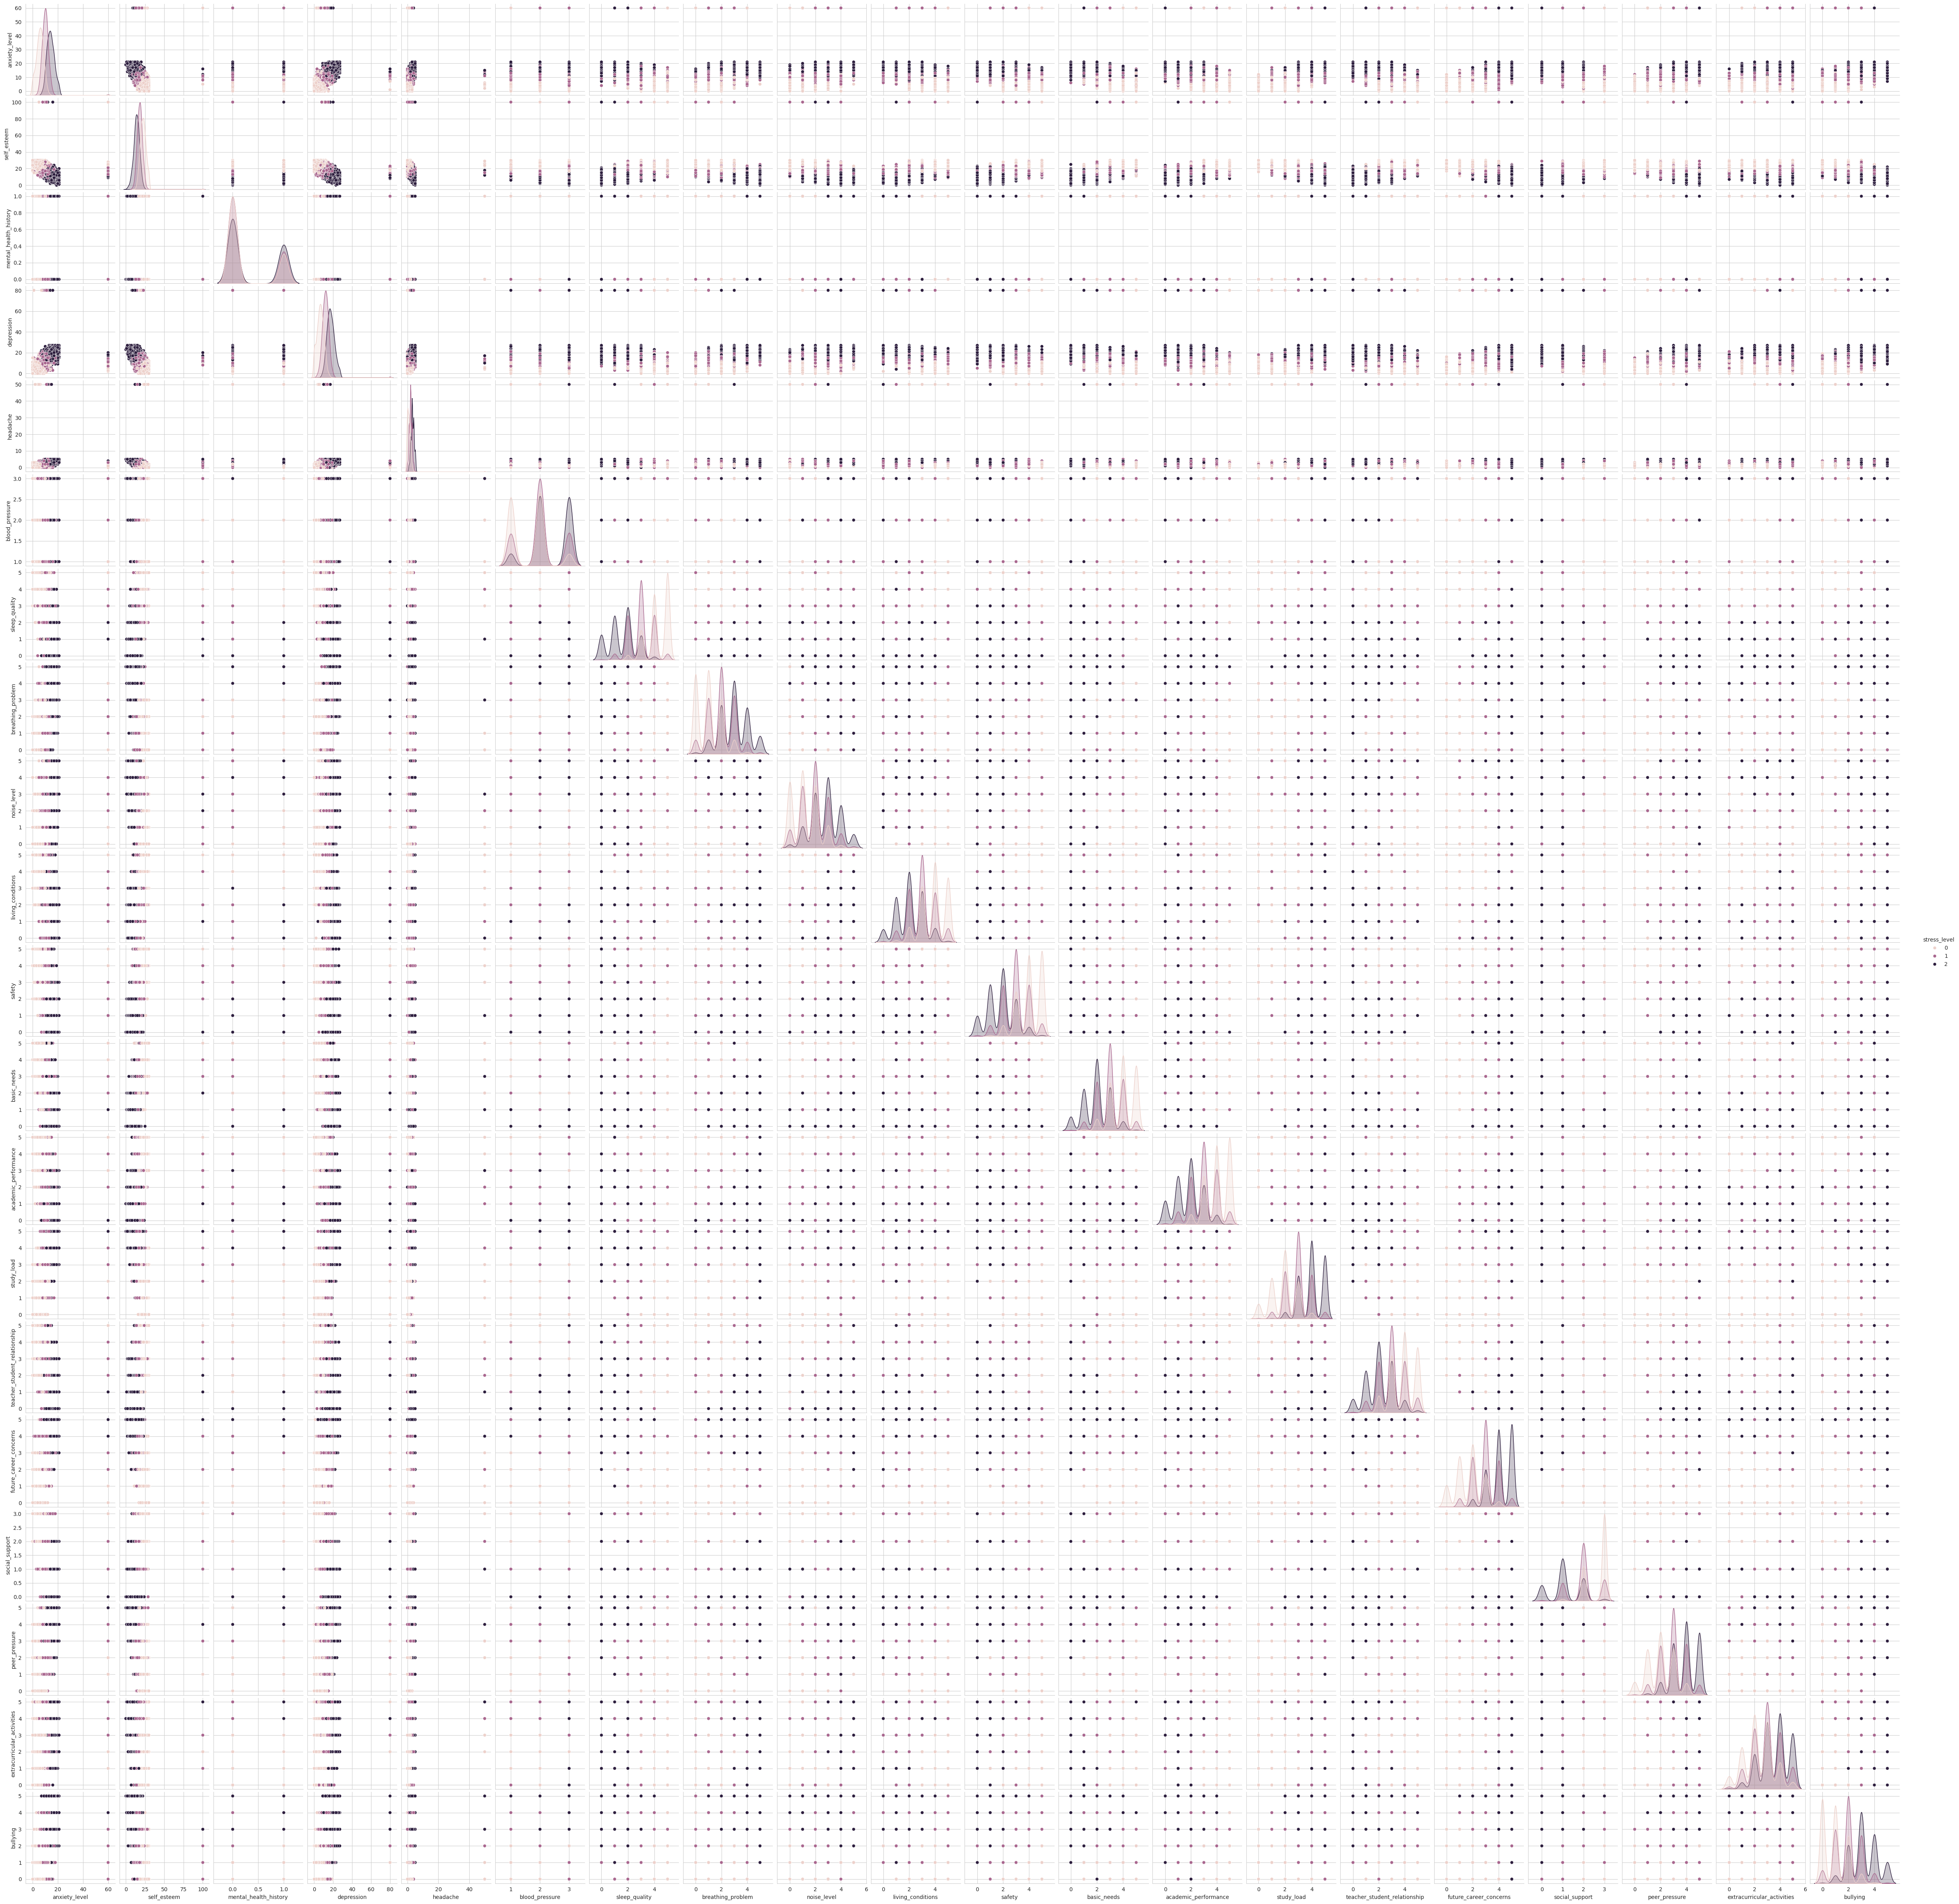

In [ ]:
sns.pairplot(
    df,
    hue='stress_level'
)

plt.show()

Сравнение accuracy моделей

In [ ]:
acc_lr = accuracy_score(y_test, pred_lr)
acc_dt = accuracy_score(y_test, pred_dt)
acc_rf = accuracy_score(y_test, pred_rf)
acc_knn = accuracy_score(y_test, pred_knn)

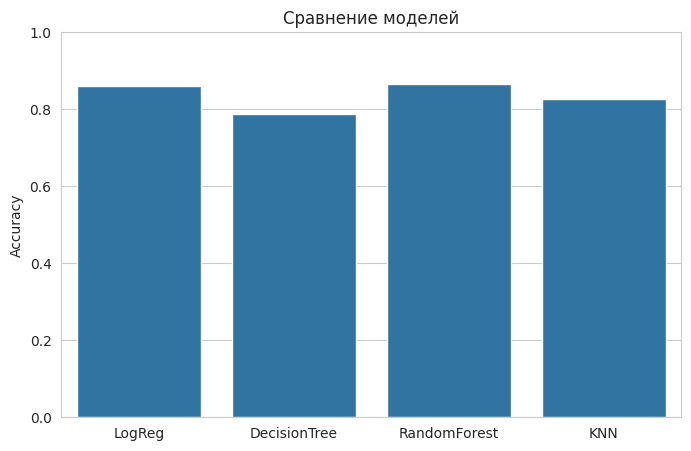

In [ ]:
models = ['LogReg', 'DecisionTree', 'RandomForest', 'KNN']

scores = [
    acc_lr,
    acc_dt,
    acc_rf,
    acc_knn
]

plt.figure(figsize=(8,5))

sns.barplot(
    x=models,
    y=scores
)

plt.ylim(0,1)

plt.title('Сравнение моделей')
plt.ylabel('Accuracy')

plt.show()

Матрица ошибок Random Forest

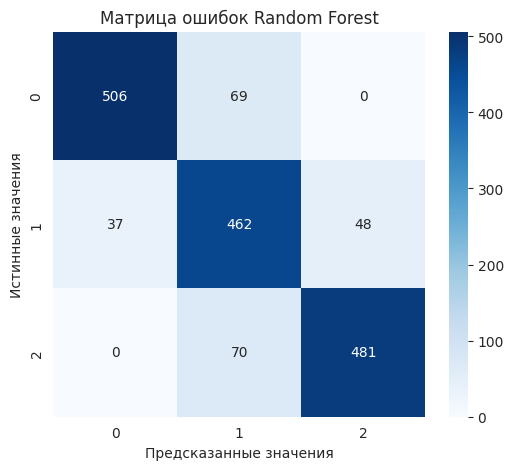

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Матрица ошибок Random Forest')
plt.xlabel('Предсказанные значения')
plt.ylabel('Истинные значения')

plt.show()

Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.88      0.91       575
           1       0.77      0.84      0.80       547
           2       0.91      0.87      0.89       551

    accuracy                           0.87      1673
   macro avg       0.87      0.87      0.87      1673
weighted avg       0.87      0.87      0.87      1673

